In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from datetime import datetime

import skeleton_plot as sklpt
import skeleton_plot.skel_io as skio

from caveclient import CAVEclient

client = CAVEclient()
client.auth.save_token(token="26091ee0f1db6f49bbf212ef6e5dcac9", overwrite=True)

# Initialize a client for the "minnie65_public" datastack.
client = CAVEclient(datastack_name='minnie65_public') 

# path to the skeleton .swc files
skel_path = "s3://bossdb-open-data/iarpa_microns/minnie/minnie65/skeletons/v661/skeletons/"

# path to the skeleton and meshwork .h5 files
mesh_path = "s3://bossdb-open-data/iarpa_microns/minnie/minnie65/skeletons/v661/meshworks/"

import random
import s3fs

fs = s3fs.S3FileSystem(anon=True)
# list all skeleton files
skel_files = fs.ls(skel_path)
print(f"Found {len(skel_files)} skeleton files")

Found 76980 skeleton files
Random skeleton file: bossdb-open-data/iarpa_microns/minnie/minnie65/skeletons/v661/skeletons/864691135394969333_494692.swc
Loaded skeleton: 864691135394969333_494692.swc


In [10]:
# add different seed for different random skeleton
random.seed(6)  # Set a random seed for reproducibility
# Pick a random skeleton file from the list
random_skel_filename = random.choice(skel_files)
print(f"Random skeleton file: {random_skel_filename}")

# Extract just the filename (if needed)
random_skel_filename = random_skel_filename.split('/')[-1]

# Load the random skeleton
sk = skio.read_skeleton(skel_path, random_skel_filename)
print(f"Loaded skeleton: {random_skel_filename}")

Random skeleton file: bossdb-open-data/iarpa_microns/minnie/minnie65/skeletons/v661/skeletons/864691136952935135_583291.swc
Loaded skeleton: 864691136952935135_583291.swc


In [11]:
# List all attributes and methods of the Skeleton object
print("Attributes and methods of the Skeleton object:")
print(dir(sk))

# Inspect key properties of the Skeleton object
print("\nKey properties of the Skeleton object:")
print(f"Root: {sk.root}")
print(f"Vertices shape: {sk.vertices.shape}")
print(f"Edges shape: {sk.edges.shape}")
print(f"Branch points: {len(sk.branch_points)}")
print(f"End points: {len(sk.end_points)}")
print(f"Segments: {len(sk.segments)}")
print(f"Segments plus: {len(sk.segments_plus)}")
print(f"Path length: {sk.path_length(sk.segments[0])} nm (example segment)")

Attributes and methods of the Skeleton object:
['SkeletonIndex', '_SkeletonIndex', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_branch_points', '_compute_cover_paths', '_compute_segments', '_cover_paths', '_create_branch_and_end_points', '_create_default_root', '_csgraph_filtered', '_edges', '_end_points', '_kdtree', '_meta', '_node_mask', '_pykdtree', '_register_skeleton_index', '_reset_derived_properties_filtered', '_reset_derived_properties_rooted', '_rooted', '_segment_map', '_segments', '_single_path_length', '_vertices', 'apply_mask', 'branch_points', 'branch_points_undirected', 'child_nodes', 'copy', 'cover_paths', 'cover_pa

In [12]:
# Select the indices associated with the dendrites
dendrite_inds = (sk.vertex_properties['compartment']==3) | (sk.vertex_properties['compartment']==4)| (sk.vertex_properties['compartment']==1) #soma is included here to connect the dendrite graphs 
# create new skeleton that masks (selects) only the dendrite indices
sk_dendrite = sk.apply_mask(dendrite_inds)

In [13]:
# Minimal dependencies
import numpy as np
import networkx as nx

def build_branch_graph(skel_or_meshwork, include_root=True, include_tips=False):
    """
    Reduce a meshparty skeleton to its branching topology.

    Parameters
    ----------
    skel_or_meshwork : meshparty.skeleton.Skeleton or meshparty.meshwork.Meshwork
        Either the Skeleton directly (nrn.skeleton) or a Meshwork (nrn).
    include_root : bool
        Include the soma/root as a topological node.
    include_tips : bool
        If True, include end points (tips) as topo nodes; otherwise only branch points (+ root).

    Returns
    -------
    G : networkx.Graph
        Nodes are skeleton-vertex indices of the selected topo points.
        Node attrs:
            - pos: (x,y,z) coordinates (same units as the skeleton, typically nm)
            - kind: 'branch' | 'root' | 'tip'
        Edge attrs:
            - length_nm: path length along the original skeleton between the two topo nodes
            - n_vertices: number of skeleton vertices along that segment/path
            - path: numpy array of the skeleton-vertex indices comprising the segment
    """
    # Accept either a Meshwork or a Skeleton
    sk = getattr(skel_or_meshwork, "skeleton", skel_or_meshwork)

    # --- Choose which topological points to keep
    topo = set(sk.branch_points)  # branch points
    if include_root and sk.root is not None:
        topo.add(int(sk.root))
    if include_tips:
        topo.update(sk.end_points)

    topo = np.array(sorted(topo), dtype=int)

    # --- Build the reduced graph by walking segments between topo nodes
    # Use segments_plus so each segment includes the parent/topo node on the rootward end.
    # (segments are defined from a branch-or-tip to the next rootward branch/root) 
    G = nx.Graph()

    # Add nodes with attributes
    for v in topo:
        kind = "branch"
        if include_root and v == sk.root:
            kind = "root"
        elif include_tips and v in set(sk.end_points.tolist()):
            kind = "tip"
        G.add_node(int(v), pos=tuple(sk.vertices[v]), kind=kind)

    # Traverse segments and keep only those whose endpoints are both selected topo nodes
    for seg in sk.segments_plus:
        u, v = int(seg[0]), int(seg[-1])  # distal topo node -> rootward topo node
        if u in G and v in G and u != v:
            # Length along the original skeleton path
            length = float(sk.path_length(seg))
            G.add_edge(u, v, length_nm=length, n_vertices=len(seg), path=seg.copy())

    # Optional: keep only the connected component containing the root (if present)
    if include_root and sk.root in G:
        cc = max(nx.connected_components(G), key=len)  # largest CC (usually the soma tree)
        if sk.root not in cc:
            # fall back to the component with the root explicitly
            for c in nx.connected_components(G):
                if sk.root in c:
                    cc = c
                    break
        G = G.subgraph(cc).copy()

    return G

In [14]:
# Branch-only topology (root included, tips excluded)
G = build_branch_graph(sk_dendrite, include_root=True, include_tips=True)

print(f"Branch nodes: {G.number_of_nodes()}, branch edges: {G.number_of_edges()}")
# Inspect one edge
u, v, data = next(iter(G.edges(data=True)))
print("Example edge:", u, "->", v, "length (µm) =", data["length_nm"]/1_000)

Branch nodes: 128, branch edges: 127
Example edge: 0 -> 9 length (µm) = 0.019517358779907228


In [15]:
# Find all nodes in G
high_degree_nodes = [node for node in G.nodes() if G.degree(node) > 3]
print("Nodes with degree > 3:", high_degree_nodes)

Nodes with degree > 3: [0, 12]


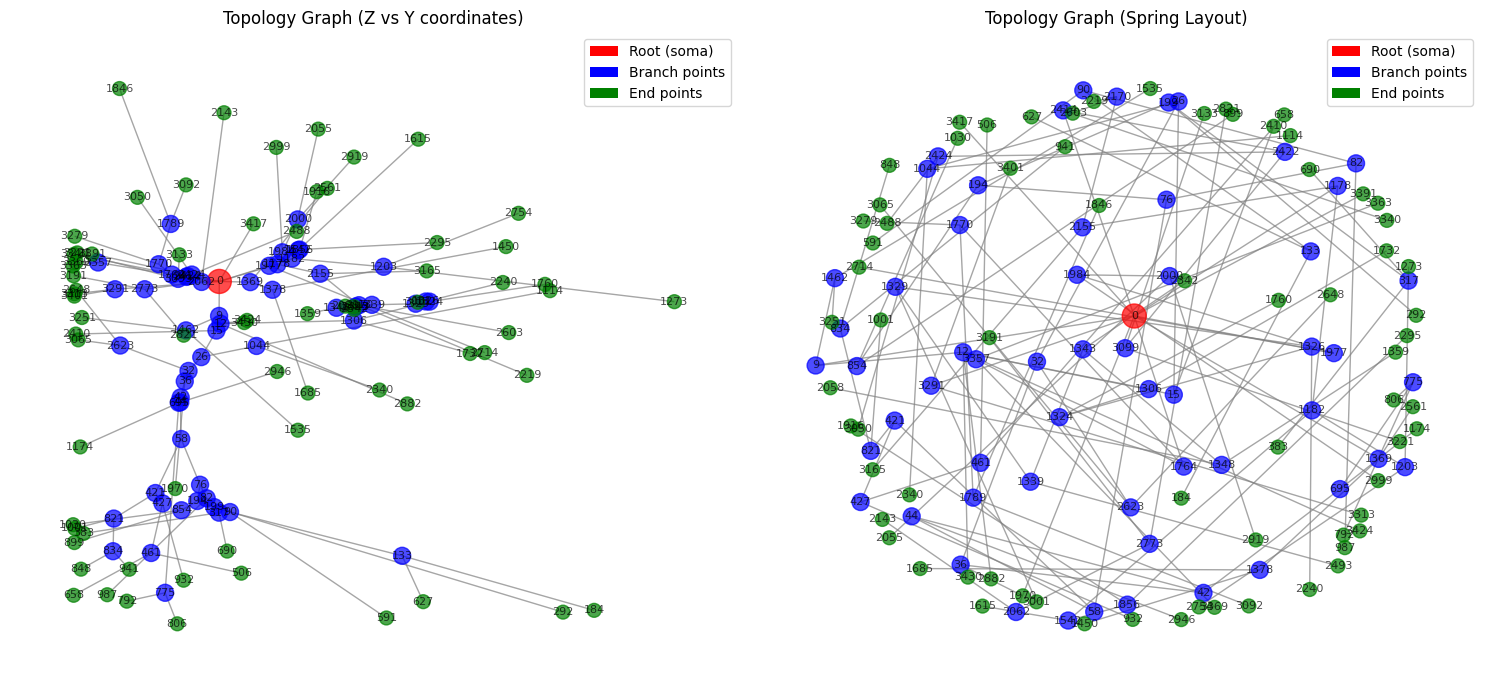

Topology Graph Statistics:
  Nodes: 128
  Edges: 127
  Root nodes: 1
  Branch nodes: 57
  Tip nodes: 70

Edge Lengths (µm):
  Mean: 0.0
  Min: 0.0
  Max: 0.1
  Total length: 5.2 µm


In [16]:
import matplotlib.pyplot as plt
import networkx as nx

# Plot the topology graph
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# Plot 1: 3D positions projected to 2D (z vs y)
pos_3d = {}
node_colors = []
node_sizes = []

for node in G.nodes():
    pos_3d[node] = (G.nodes[node]['pos'][2], G.nodes[node]['pos'][1])  # z, y coordinates
    
    # Color nodes by type
    if G.nodes[node]['kind'] == 'root':
        node_colors.append('red')
        node_sizes.append(300)
    elif G.nodes[node]['kind'] == 'branch':
        node_colors.append('blue')
        node_sizes.append(150)
    elif G.nodes[node]['kind'] == 'tip':
        node_colors.append('green')
        node_sizes.append(100)

# Draw the graph with 3D positions
nx.draw(G, pos_3d, ax=ax1, 
        node_color=node_colors, 
        node_size=node_sizes,
        with_labels=True, 
        font_size=8,
        edge_color='gray',
        alpha=0.7)

ax1.set_title('Topology Graph (Z vs Y coordinates)')
ax1.set_xlabel('Z (nm)')
ax1.set_ylabel('Y (nm)')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='Root (soma)'),
                   Patch(facecolor='blue', label='Branch points'),
                   Patch(facecolor='green', label='End points')]
ax1.legend(handles=legend_elements, loc='upper right')

# Plot 2: Spring layout for better topology visualization
pos_spring = nx.spring_layout(G, k=1, iterations=50)

nx.draw(G, pos_spring, ax=ax2,
        node_color=node_colors,
        node_size=node_sizes,
        with_labels=True,
        font_size=8,
        edge_color='gray',
        alpha=0.7)

ax2.set_title('Topology Graph (Spring Layout)')
ax2.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Print some statistics about the topology
print(f"Topology Graph Statistics:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Root nodes: {sum(1 for n in G.nodes() if G.nodes[n]['kind'] == 'root')}")
print(f"  Branch nodes: {sum(1 for n in G.nodes() if G.nodes[n]['kind'] == 'branch')}")
print(f"  Tip nodes: {sum(1 for n in G.nodes() if G.nodes[n]['kind'] == 'tip')}")

# Show edge lengths
edge_lengths = [data['length_nm']/1000 for u, v, data in G.edges(data=True)]  # Convert to micrometers
print(f"\nEdge Lengths (µm):")
print(f"  Mean: {np.mean(edge_lengths):.1f}")
print(f"  Min: {np.min(edge_lengths):.1f}")
print(f"  Max: {np.max(edge_lengths):.1f}")
print(f"  Total length: {np.sum(edge_lengths):.1f} µm")